In [10]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [11]:
import os
import zipfile

zip_path = "/content/archive (4).zip"
extract_path = "/content/UNSW_NB15"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted successfully!")

Files extracted successfully!


In [12]:
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

/content/UNSW_NB15/UNSW_NB15_testing-set.parquet
/content/UNSW_NB15/UNSW_NB15_training-set.parquet


In [13]:
train_df = pd.read_parquet(
    "/content/UNSW_NB15/UNSW_NB15_training-set.parquet"
)

test_df = pd.read_parquet(
    "/content/UNSW_NB15/UNSW_NB15_testing-set.parquet"
)

print("Train Data Loaded Successfully")
print("Test Data Loaded Successfully")

Train Data Loaded Successfully
Test Data Loaded Successfully


In [14]:
# Check Train and Test Dataset Shape

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape: (175341, 36)
Test Shape : (82332, 36)


In [15]:
# Preview Train and Test Data

display(train_df.head())
display(test_df.head())

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.000011,udp,-,INT,2,0,496,0,90909.09375,180363632.0,...,0,0,1,1,0,0,0,0,Normal,0
1,0.000008,udp,-,INT,2,0,1762,0,125000.00000,881000000.0,...,0,0,1,1,0,0,0,0,Normal,0
2,0.000005,udp,-,INT,2,0,1068,0,200000.00000,854400000.0,...,0,0,1,1,0,0,0,0,Normal,0
3,0.000006,udp,-,INT,2,0,900,0,166666.65625,600000000.0,...,0,0,2,1,0,0,0,0,Normal,0
4,0.000010,udp,-,INT,2,0,2126,0,100000.00000,850400000.0,...,0,0,2,1,0,0,0,0,Normal,0


In [16]:
# Check Columns and Data Types

print("Dataset Columns:")
print(train_df.columns.tolist())

print("\nData Types:")
print(train_df.dtypes)

Dataset Columns:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']

Data Types:
dur                   float32
proto                category
service              category
state                category
spkts                   int16
dpkts                   int16
sbytes                  int32
dbytes                  int32
rate                  float32
sload                 float32
dload                 float32
sloss                   int16
dloss                   int16
sinpkt                float32
dinpkt                float32
sjit                  float32
djit                  float32
swin                    int16
stcpb                   i

In [17]:
# Check Dataset Information

print("TRAIN DATA INFO")
print("=" * 50)
train_df.info()

print("\nTEST DATA INFO")
print("=" * 50)
test_df.info()

TRAIN DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 36 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   dur                175341 non-null  float32 
 1   proto              175341 non-null  category
 2   service            175341 non-null  category
 3   state              175341 non-null  category
 4   spkts              175341 non-null  int16   
 5   dpkts              175341 non-null  int16   
 6   sbytes             175341 non-null  int32   
 7   dbytes             175341 non-null  int32   
 8   rate               175341 non-null  float32 
 9   sload              175341 non-null  float32 
 10  dload              175341 non-null  float32 
 11  sloss              175341 non-null  int16   
 12  dloss              175341 non-null  int16   
 13  sinpkt             175341 non-null  float32 
 14  dinpkt             175341 non-null  float32 
 15  sjit              

In [18]:
# Check Missing Values

print("Missing Values in Train:")
print(train_df.isnull().sum())

print("\nTotal Missing Values in Train:", train_df.isnull().sum().sum())

print("\nMissing Values in Test:")
print(test_df.isnull().sum())

print("\nTotal Missing Values in Test:", test_df.isnull().sum().sum())

Missing Values in Train:
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
is_sm_ips_ports      0
attack_cat           0
label                0
dtype: int64

Total Missing Values in Train: 0

Missing Values in Test:
dur                  0
proto                0
service              0
state 

In [19]:
# Check Duplicate Rows

print("Duplicate Rows in Train:", train_df.duplicated().sum())
print("Duplicate Rows in Test :", test_df.duplicated().sum())

Duplicate Rows in Train: 78519
Duplicate Rows in Test : 32361


In [20]:
# Check Target Class Distribution

print("Train Label Distribution:")
print(train_df["label"].value_counts())

print("\nTrain Label Percentage:")
print(train_df["label"].value_counts(normalize=True) * 100)

print("\nTest Label Distribution:")
print(test_df["label"].value_counts())

print("\nTest Label Percentage:")
print(test_df["label"].value_counts(normalize=True) * 100)

Train Label Distribution:
label
1    119341
0     56000
Name: count, dtype: int64

Train Label Percentage:
label
1    68.062233
0    31.937767
Name: proportion, dtype: float64

Test Label Distribution:
label
1    45332
0    37000
Name: count, dtype: int64

Test Label Percentage:
label
1    55.060001
0    44.939999
Name: proportion, dtype: float64


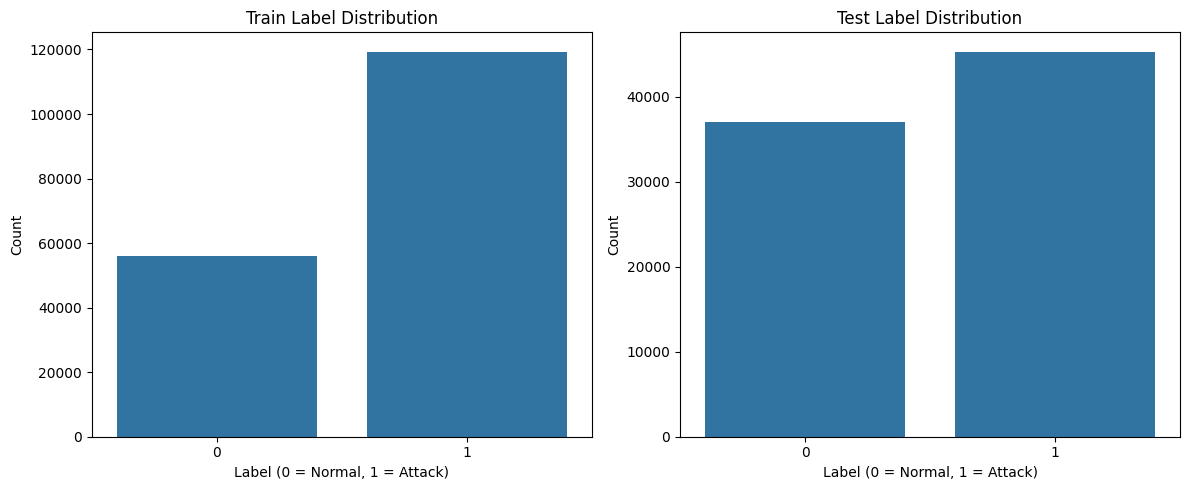

In [21]:
# Visualize Target Class Distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=train_df, x="label", ax=axes[0])
axes[0].set_title("Train Label Distribution")
axes[0].set_xlabel("Label (0 = Normal, 1 = Attack)")
axes[0].set_ylabel("Count")

sns.countplot(data=test_df, x="label", ax=axes[1])
axes[1].set_title("Test Label Distribution")
axes[1].set_xlabel("Label (0 = Normal, 1 = Attack)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [22]:
# Check Attack Categories Distribution

print("Train Attack Categories:")
print(train_df["attack_cat"].value_counts())

print("\nTest Attack Categories:")
print(test_df["attack_cat"].value_counts())

Train Attack Categories:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

Test Attack Categories:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


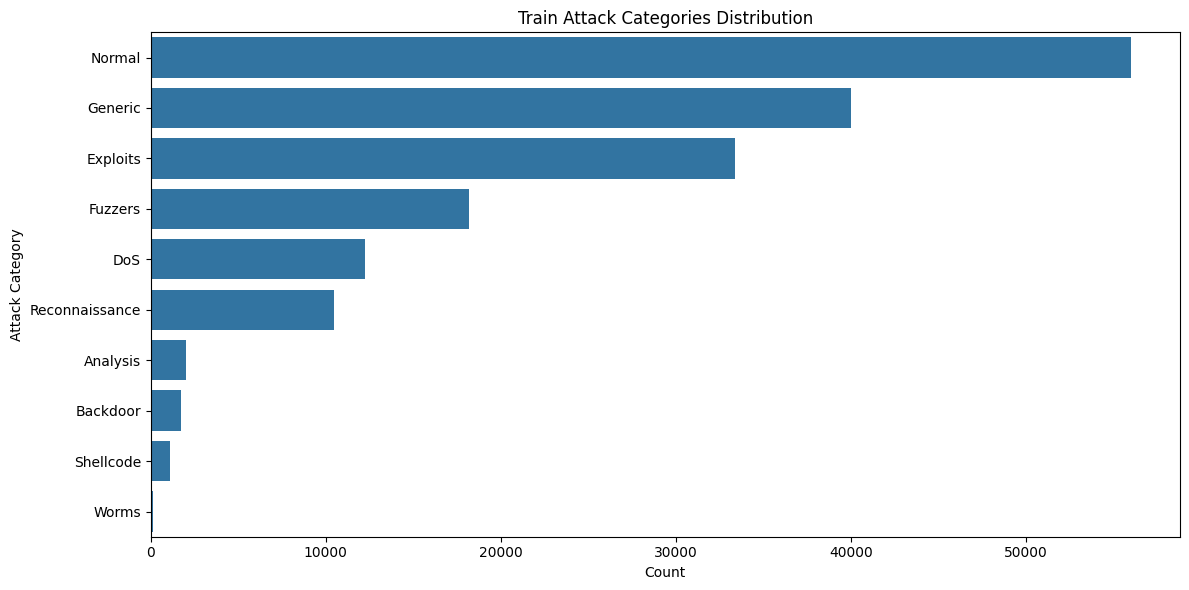

In [23]:
# Visualize Attack Categories Distribution

plt.figure(figsize=(12, 6))

sns.countplot(
    data=train_df,
    y="attack_cat",
    order=train_df["attack_cat"].value_counts().index
)

plt.title("Train Attack Categories Distribution")
plt.xlabel("Count")
plt.ylabel("Attack Category")

plt.tight_layout()
plt.show()

In [24]:
# Numerical Features Statistics

train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
dur,175341.0,1.359389e+00,6.483313e+00,0.0,0.000008,0.001582,6.680690e-01,5.999999e+01
spkts,175341.0,2.029866e+01,1.368876e+02,1.0,2.000000,2.000000,1.200000e+01,9.616000e+03
dpkts,175341.0,1.896959e+01,1.102583e+02,0.0,0.000000,2.000000,1.000000e+01,1.097400e+04
sbytes,175341.0,8.844844e+03,1.747656e+05,28.0,114.000000,430.000000,1.418000e+03,1.296523e+07
dbytes,175341.0,1.492892e+04,1.436542e+05,0.0,0.000000,164.000000,1.102000e+03,1.465555e+07
rate,175341.0,9.540618e+04,1.654177e+05,0.0,32.786140,3225.806641,1.250000e+05,1.000000e+06
sload,175341.0,7.345403e+07,1.883701e+08,0.0,13053.338867,879674.750000,8.888889e+07,5.988000e+09
dload,175341.0,6.712055e+05,2.423637e+06,0.0,0.000000,1447.022705,2.784487e+04,2.242273e+07
sloss,175341.0,4.953000e+00,6.600506e+01,0.0,0.000000,0.000000,3.000000e+00,4.803000e+03
dloss,175341.0,6.948010e+00,5.273300e+01,0.0,0.000000,0.000000,2.000000e+00,5.484000e+03


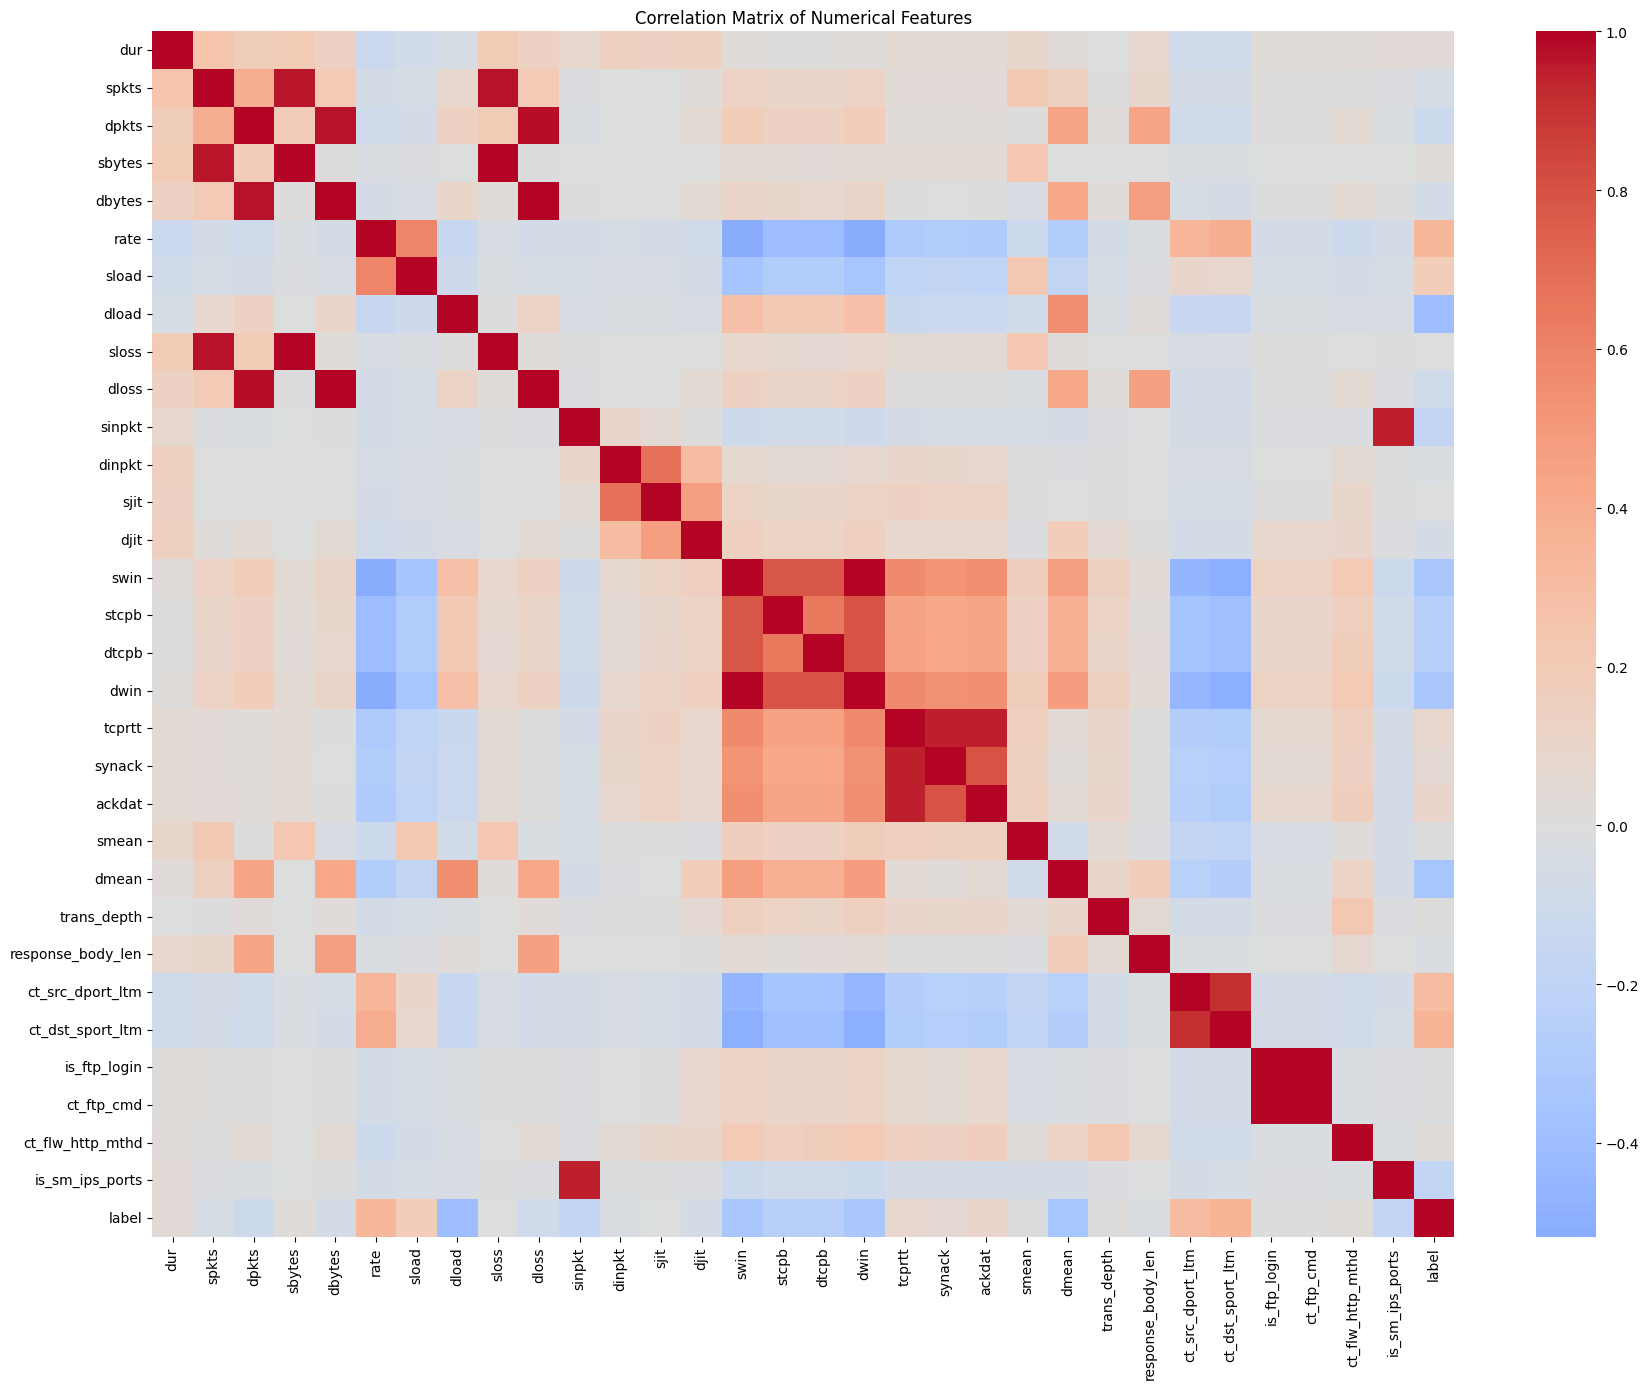

In [25]:
# Correlation Matrix

numeric_df = train_df.select_dtypes(include=["number"])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [26]:
# Correlation with Target Label

label_corr = corr_matrix["label"].drop("label").sort_values(ascending=False)

print("Correlation with Label:")
print(label_corr)

Correlation with Label:
ct_dst_sport_ltm     0.357213
rate                 0.337979
ct_src_dport_ltm     0.305579
sload                0.182870
ackdat               0.097364
tcprtt               0.081584
synack               0.058299
dur                  0.036175
sbytes               0.018576
ct_flw_http_mthd     0.015800
trans_depth          0.010801
sloss               -0.000640
sjit                -0.007069
smean               -0.010798
ct_ftp_cmd          -0.011055
is_ftp_login        -0.011055
response_body_len   -0.021361
dinpkt              -0.022887
spkts               -0.052178
djit                -0.060870
dbytes              -0.076871
dloss               -0.094685
dpkts               -0.118591
sinpkt              -0.176110
is_sm_ips_ports     -0.184679
dtcpb               -0.250340
stcpb               -0.255006
dwin                -0.319626
swin                -0.333633
dmean               -0.341806
dload               -0.393739
Name: label, dtype: float64


In [27]:
# Categorical Features Summary

categorical_cols = ["proto", "service", "state", "attack_cat"]

for col in categorical_cols:
    print(f"\n{col}")
    print("-" * 40)
    print("Number of unique values:", train_df[col].nunique())
    print(train_df[col].value_counts().head(15))


proto
----------------------------------------
Number of unique values: 133
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
swipe       201
mobile      201
pim         201
sun-nd      201
ipv6        201
rsvp        200
sep         193
Name: count, dtype: int64

service
----------------------------------------
Number of unique values: 13
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
ssl            56
irc            25
radius         12
Name: count, dtype: int64

state
----------------------------------------
Number of unique values: 9
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64

attack_cat
----------------------------------------
Number of unique values: 10


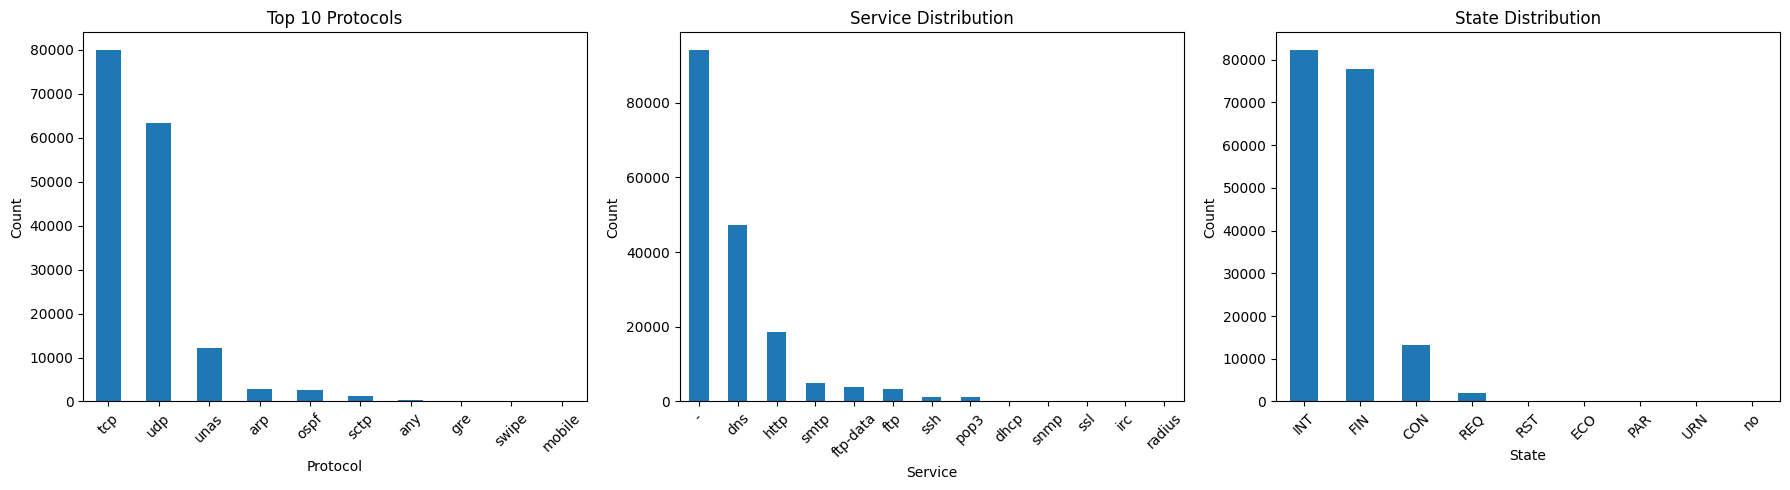

In [28]:
# Visualize Main Categorical Features

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

train_df["proto"].value_counts().head(10).plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("Top 10 Protocols")
axes[0].set_xlabel("Protocol")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

train_df["service"].value_counts().plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("Service Distribution")
axes[1].set_xlabel("Service")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

train_df["state"].value_counts().plot(
    kind="bar",
    ax=axes[2]
)
axes[2].set_title("State Distribution")
axes[2].set_xlabel("State")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

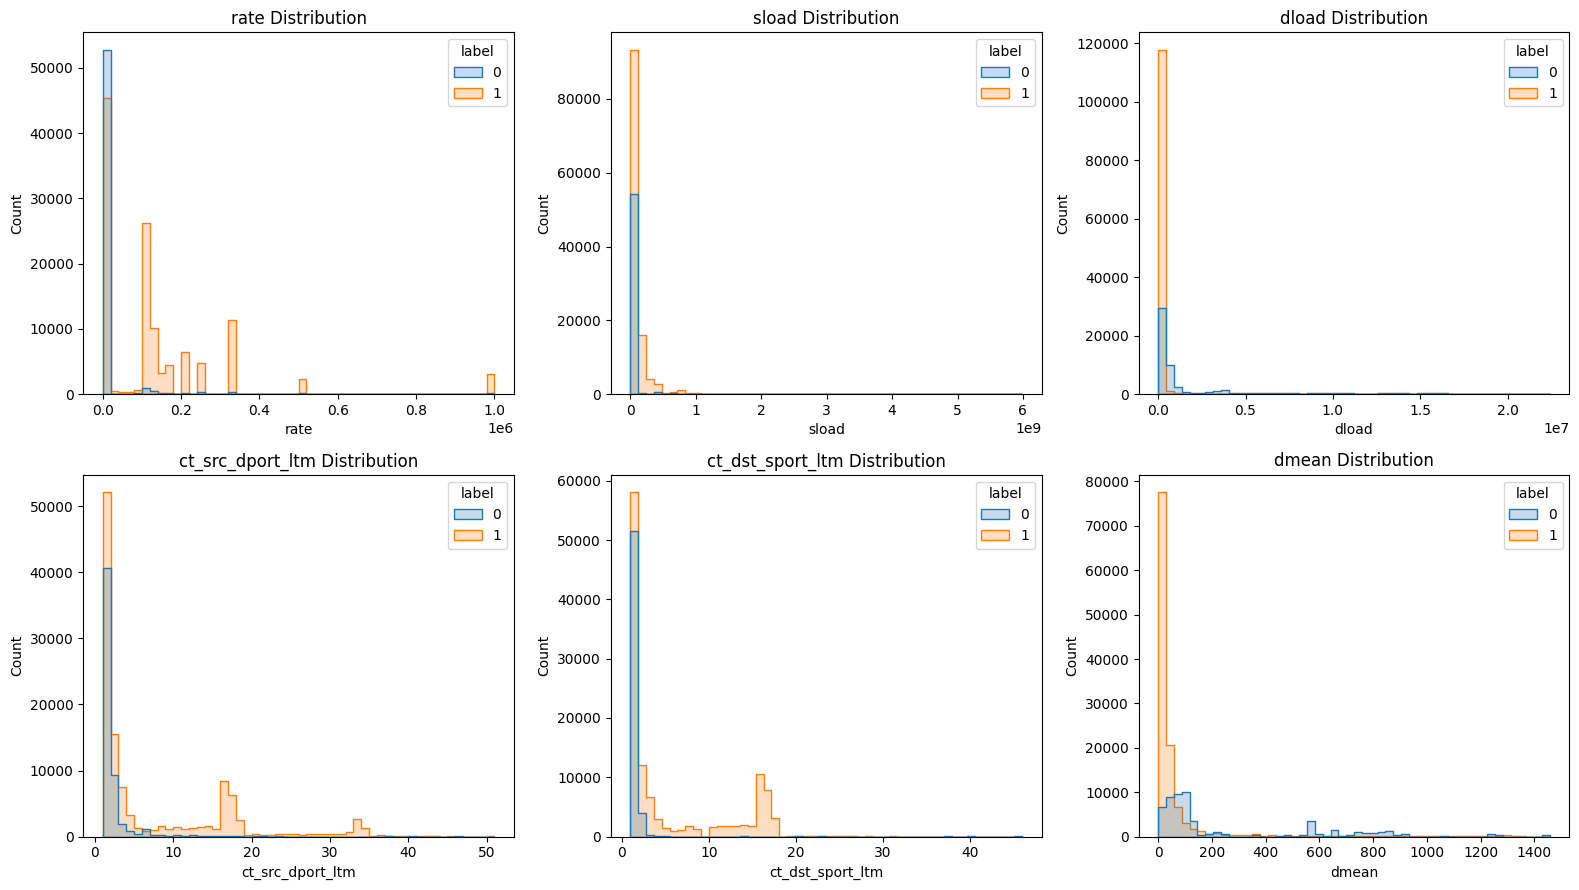

In [29]:
# Important Numerical Features Distribution

features = ["rate", "sload", "dload", "ct_src_dport_ltm", "ct_dst_sport_ltm", "dmean"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for feature, ax in zip(features, axes.flatten()):
    sns.histplot(
        data=train_df,
        x=feature,
        hue="label",
        bins=50,
        ax=ax,
        element="step"
    )
    ax.set_title(f"{feature} Distribution")

plt.tight_layout()
plt.show()

In [30]:
# EDA Summary

print("EDA SUMMARY")
print("=" * 60)

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

print("\nMissing Values:")
print("Train:", train_df.isnull().sum().sum())
print("Test :", test_df.isnull().sum().sum())

print("\nDuplicate Rows:")
print("Train:", train_df.duplicated().sum())
print("Test :", test_df.duplicated().sum())

print("\nTrain Target Distribution:")
print(train_df["label"].value_counts(normalize=True) * 100)

print("\nTest Target Distribution:")
print(test_df["label"].value_counts(normalize=True) * 100)

print("\nNumber of Attack Categories:")
print(train_df["attack_cat"].nunique())

print("\nNumber of Unique Protocols:")
print(train_df["proto"].nunique())

print("\nTop Positive Correlations with Label:")
print(label_corr.head(5))

print("\nTop Negative Correlations with Label:")
print(label_corr.tail(5))

EDA SUMMARY
Train Shape: (175341, 36)
Test Shape : (82332, 36)

Missing Values:
Train: 0
Test : 0

Duplicate Rows:
Train: 78519
Test : 32361

Train Target Distribution:
label
1    68.062233
0    31.937767
Name: proportion, dtype: float64

Test Target Distribution:
label
1    55.060001
0    44.939999
Name: proportion, dtype: float64

Number of Attack Categories:
10

Number of Unique Protocols:
133

Top Positive Correlations with Label:
ct_dst_sport_ltm    0.357213
rate                0.337979
ct_src_dport_ltm    0.305579
sload               0.182870
ackdat              0.097364
Name: label, dtype: float64

Top Negative Correlations with Label:
stcpb   -0.255006
dwin    -0.319626
swin    -0.333633
dmean   -0.341806
dload   -0.393739
Name: label, dtype: float64


In [31]:
# ==========================================
# MEMBER 2 -  DATA CLEANING


print("Before removing duplicates:")
print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

# Remove duplicate rows
train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()

print("\nAfter removing duplicates:")
print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

# Verify duplicates were removed
print("\nRemaining Duplicates:")
print("Train:", train_df.duplicated().sum())
print("Test :", test_df.duplicated().sum())

Before removing duplicates:
Train Shape: (175341, 36)
Test Shape : (82332, 36)

After removing duplicates:
Train Shape: (96822, 36)
Test Shape : (49971, 36)

Remaining Duplicates:
Train: 0
Test : 0


In [32]:
#  DEFINE FEATURES AND TARGET

X_train = train_df.drop(columns=["label", "attack_cat"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["label", "attack_cat"])
y_test = test_df["label"]

print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (96822, 34)
y_train Shape: (96822,)
X_test Shape: (49971, 34)
y_test Shape: (49971,)


In [33]:
# IDENTIFY FEATURE TYPES

categorical_cols = ["proto", "service", "state"]

numerical_cols = X_train.select_dtypes(
    include=["int8", "int16", "int32", "int64", "float32", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_cols)

print("\nNumber of Numerical Features:", len(numerical_cols))
print(numerical_cols)

Categorical Features:
['proto', 'service', 'state']

Number of Numerical Features: 31
['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports']


In [34]:
# ENCODING

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])

X_test_cat = encoder.transform(X_test[categorical_cols])

print("Encoded Train Shape:", X_train_cat.shape)
print("Encoded Test Shape :", X_test_cat.shape)

Encoded Train Shape: (96822, 155)
Encoded Test Shape : (49971, 155)


In [35]:
# FEATURE SCALING
scaler = StandardScaler()

X_train_num = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test_num = scaler.transform(
    X_test[numerical_cols]
)

print("Scaled Train Shape:", X_train_num.shape)
print("Scaled Test Shape :", X_test_num.shape)

Scaled Train Shape: (96822, 31)
Scaled Test Shape : (49971, 31)


In [36]:
# COMBINE FEATURES


X_train_processed = np.hstack(
    [X_train_num, X_train_cat]
)

X_test_processed = np.hstack(
    [X_test_num, X_test_cat]
)

print("Final X_train Shape:", X_train_processed.shape)
print("Final X_test Shape :", X_test_processed.shape)

Final X_train Shape: (96822, 186)
Final X_test Shape : (49971, 186)


In [37]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

Before SMOTE:
label
0    48894
1    47928
Name: count, dtype: int64

After SMOTE:
label
0    48894
1    48894
Name: count, dtype: int64


In [38]:
# FINAL PREPROCESSING CHECK

print("FINAL DATA CHECK")
print("=" * 50)

print("\nTraining Data:")
print("X_train_resampled:", X_train_resampled.shape)
print("y_train_resampled:", y_train_resampled.shape)

print("\nTesting Data:")
print("X_test_processed:", X_test_processed.shape)
print("y_test:", y_test.shape)

print("\nClass Distribution After SMOTE:")
print(y_train_resampled.value_counts())

print("\nMissing Values in Final Arrays:")
print("Train:", np.isnan(X_train_resampled).sum())
print("Test :", np.isnan(X_test_processed).sum())

FINAL DATA CHECK

Training Data:
X_train_resampled: (97788, 186)
y_train_resampled: (97788,)

Testing Data:
X_test_processed: (49971, 186)
y_test: (49971,)

Class Distribution After SMOTE:
label
0    48894
1    48894
Name: count, dtype: int64

Missing Values in Final Arrays:
Train: 0
Test : 0


# MEMBER 3 - BASELINE ML MODELS


In [39]:
# ==========================================
# IMPORT MODELS & METRICS
# ==========================================

import time

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


In [40]:
# ==========================================
# HELPER FUNCTION - TRAIN & EVALUATE
# ==========================================

results = {}

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """Train a model, evaluate it, and store/print its metrics."""

    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)

    # ROC-AUC needs probability scores (if available)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "Train Time (s)": train_time
    }

    print(f"===== {name} =====")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")
    print(f"Train Time: {train_time:.2f}s")
    print("\nConfusion Matrix:")
    print(cm)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Attack"],
                yticklabels=["Normal", "Attack"])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return model


## 1) Logistic Regression


===== Logistic Regression =====
Accuracy  : 0.7256
Precision : 0.5783
Recall    : 0.9355
F1-Score  : 0.7147
ROC-AUC   : 0.8260
Train Time: 11.20s

Confusion Matrix:
[[19085 12525]
 [ 1185 17176]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.60      0.74     31610
           1       0.58      0.94      0.71     18361

    accuracy                           0.73     49971
   macro avg       0.76      0.77      0.73     49971
weighted avg       0.81      0.73      0.73     49971



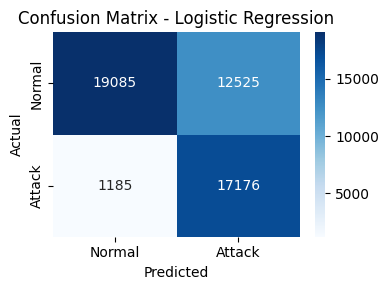

In [41]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg = evaluate_model(
    "Logistic Regression",
    log_reg,
    X_train_resampled, y_train_resampled,
    X_test_processed, y_test
)


## 2) K-Nearest Neighbors (KNN)


===== KNN =====
Accuracy  : 0.7687
Precision : 0.6260
Recall    : 0.9202
F1-Score  : 0.7451
ROC-AUC   : 0.8893
Train Time: 0.02s

Confusion Matrix:
[[21517 10093]
 [ 1466 16895]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.68      0.79     31610
           1       0.63      0.92      0.75     18361

    accuracy                           0.77     49971
   macro avg       0.78      0.80      0.77     49971
weighted avg       0.82      0.77      0.77     49971



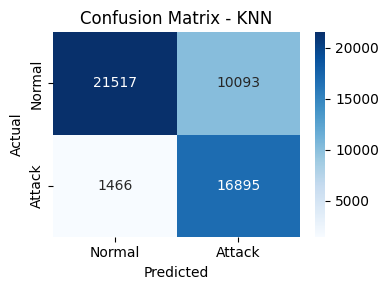

In [42]:
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

knn = evaluate_model(
    "KNN",
    knn,
    X_train_resampled, y_train_resampled,
    X_test_processed, y_test
)


## 3) Decision Tree


===== Decision Tree =====
Accuracy  : 0.7973
Precision : 0.6554
Recall    : 0.9454
F1-Score  : 0.7742
ROC-AUC   : 0.9445
Train Time: 4.16s

Confusion Matrix:
[[22484  9126]
 [ 1002 17359]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     31610
           1       0.66      0.95      0.77     18361

    accuracy                           0.80     49971
   macro avg       0.81      0.83      0.80     49971
weighted avg       0.85      0.80      0.80     49971



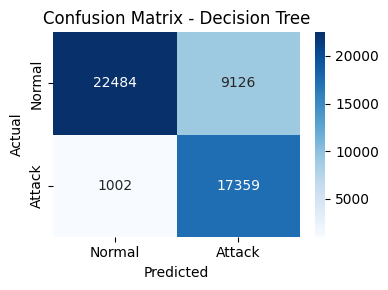

In [43]:
dt = DecisionTreeClassifier(max_depth=15, random_state=42)

dt = evaluate_model(
    "Decision Tree",
    dt,
    X_train_resampled, y_train_resampled,
    X_test_processed, y_test
)


## 4) Naive Bayes
**Note:** GaussianNB is used since the features are a mix of standardized numerical data and one-hot encoded categorical data (continuous-valued after preprocessing). Given the strong feature independence assumption, Naive Bayes is expected to underperform compared to the other models on this dataset — it's included here as a baseline for comparison, not as a top candidate.


===== Naive Bayes =====
Accuracy  : 0.6861
Precision : 0.9993
Recall    : 0.1459
F1-Score  : 0.2546
ROC-AUC   : 0.5947
Train Time: 0.21s

Confusion Matrix:
[[31608     2]
 [15683  2678]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80     31610
           1       1.00      0.15      0.25     18361

    accuracy                           0.69     49971
   macro avg       0.83      0.57      0.53     49971
weighted avg       0.79      0.69      0.60     49971



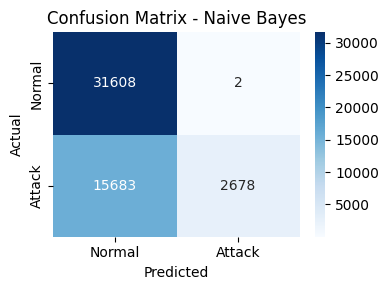

In [44]:
nb_model = GaussianNB()

nb_model = evaluate_model(
    "Naive Bayes",
    nb_model,
    X_train_resampled, y_train_resampled,
    X_test_processed, y_test
)


## Baseline Models Comparison


BASELINE MODELS COMPARISON


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
Decision Tree,0.797322,0.655428,0.945428,0.774160,0.944491,4.155174
KNN,0.768686,0.626019,0.920157,0.745110,0.889257,0.018561
Logistic Regression,0.725641,0.578297,0.935461,0.714743,0.826008,11.201380
Naive Bayes,0.686118,0.999254,0.145853,0.254551,0.594677,0.208522


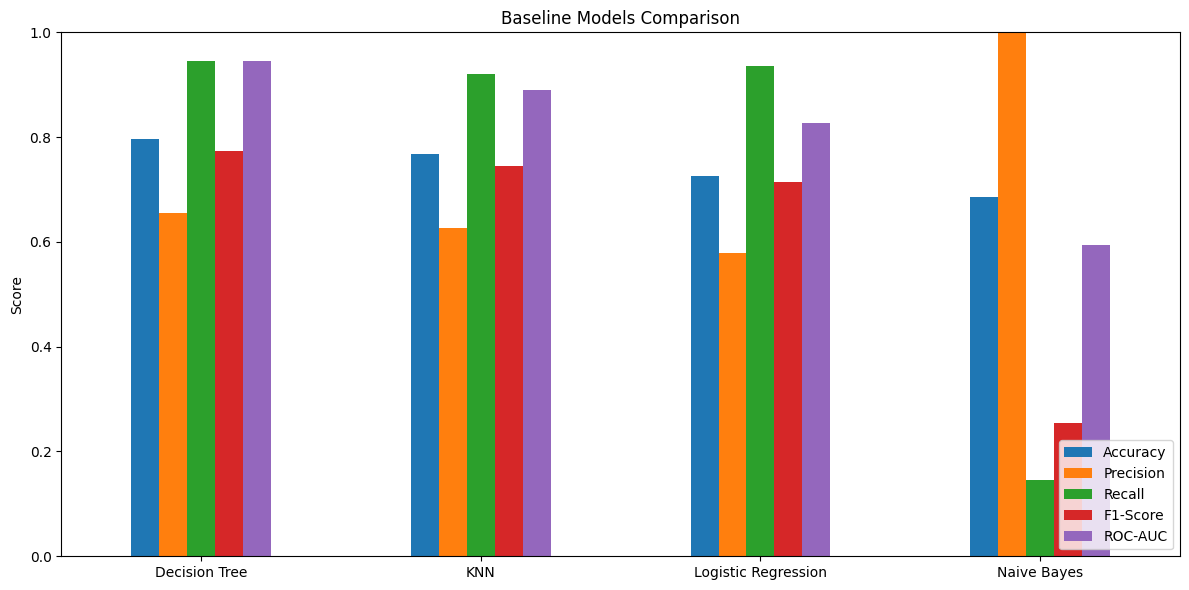


Best Model by F1-Score: Decision Tree


In [45]:
# ==========================================
# COMPARE ALL BASELINE MODELS
# ==========================================

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="F1-Score", ascending=False)

print("BASELINE MODELS COMPARISON")
print("=" * 60)
display(results_df)

# Visualize comparison
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

results_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(12, 6)
)
plt.title("Baseline Models Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("\nBest Model by F1-Score:", results_df["F1-Score"].idxmax())
